In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches


In [2]:
# Read in the processed dataset
file_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(file_path)

C:\Users\sbout\AppData\Local\Temp\ipykernel_25984\955667600.py:3: DtypeWarning: Columns (46,48,75,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


In [3]:
df.describe()

,county_fips,median_listing_price_x,median_listing_price_mm_x,median_listing_price_yy_x,active_listing_count,active_listing_count_mm,active_listing_count_yy,median_days_on_market_x,median_days_on_market_mm_x,median_days_on_market_yy_x,...,Investor Purchases YoY,U.S. 30 year FRM,30 year fees & points,U.S. 15 year FRM,15 year fees & points,U.S. 5/1 ARM,5/1 year fees & points,U.S. 5/1 ARM margin,30 year FRM / 5/1 ARM spread,highest_category
count,360053.00000,3.600280e+05,322557.000000,321231.000000,360053.000000,322486.000000,321071.000000,359710.000000,322246.000000,320783.000000,...,155604.000000,360053.000000,238692.000000,360053.000000,238692.000000,238692.000000,238692.000000,238692.000000,238692.000000,18676.000000
mean,30307.92485,2.703053e+05,0.017487,0.120064,292.939042,0.009125,0.078057,74.318448,0.046456,0.100056,...,2.635647,4.844304,0.611065,4.172829,0.590817,3.358747,0.339297,2.750027,0.563095,2.666577
std,15154.92739,2.194439e+05,1.059819,0.935075,867.790716,0.192785,0.773584,35.048294,0.433508,1.373417,...,12.254084,1.495556,0.128521,1.441222,0.157097,0.657493,0.070461,0.007652,0.360221,1.105875
min,1001.00000,1.000000e+00,-0.997100,-0.996800,0.000000,-1.000000,-1.000000,1.000000,-0.996700,-0.994800,...,-21.666667,2.684000,0.440000,2.145000,0.400000,2.422500,0.200000,2.737500,-0.237500,1.000000
25%,18167.00000,1.499250e+05,-0.027600,-0.032100,26.000000,-0.073500,-0.225800,50.000000,-0.092500,-0.193500,...,-3.333333,3.616000,0.500000,3.027500,0.480000,2.888000,0.300000,2.747500,0.300000,2.000000
50%,29153.00000,2.250000e+05,0.000000,0.056400,74.000000,0.000000,-0.017500,68.000000,0.044900,-0.014300,...,1.666667,4.444000,0.550000,3.906000,0.520000,3.226000,0.325000,2.750000,0.642500,3.000000
75%,45063.00000,3.300000e+05,0.035000,0.174500,226.000000,0.066700,0.242700,92.000000,0.164600,0.196700,...,6.000000,6.428000,0.700000,5.682000,0.680000,3.695000,0.400000,2.750000,0.792000,4.000000
max,56045.00000,1.300000e+07,570.319600,222.874900,23258.000000,32.500000,91.500000,365.000000,114.000000,266.000000,...,96.000000,7.620000,0.900000,6.905000,1.150000,6.005000,0.500000,2.770000,1.287500,4.000000


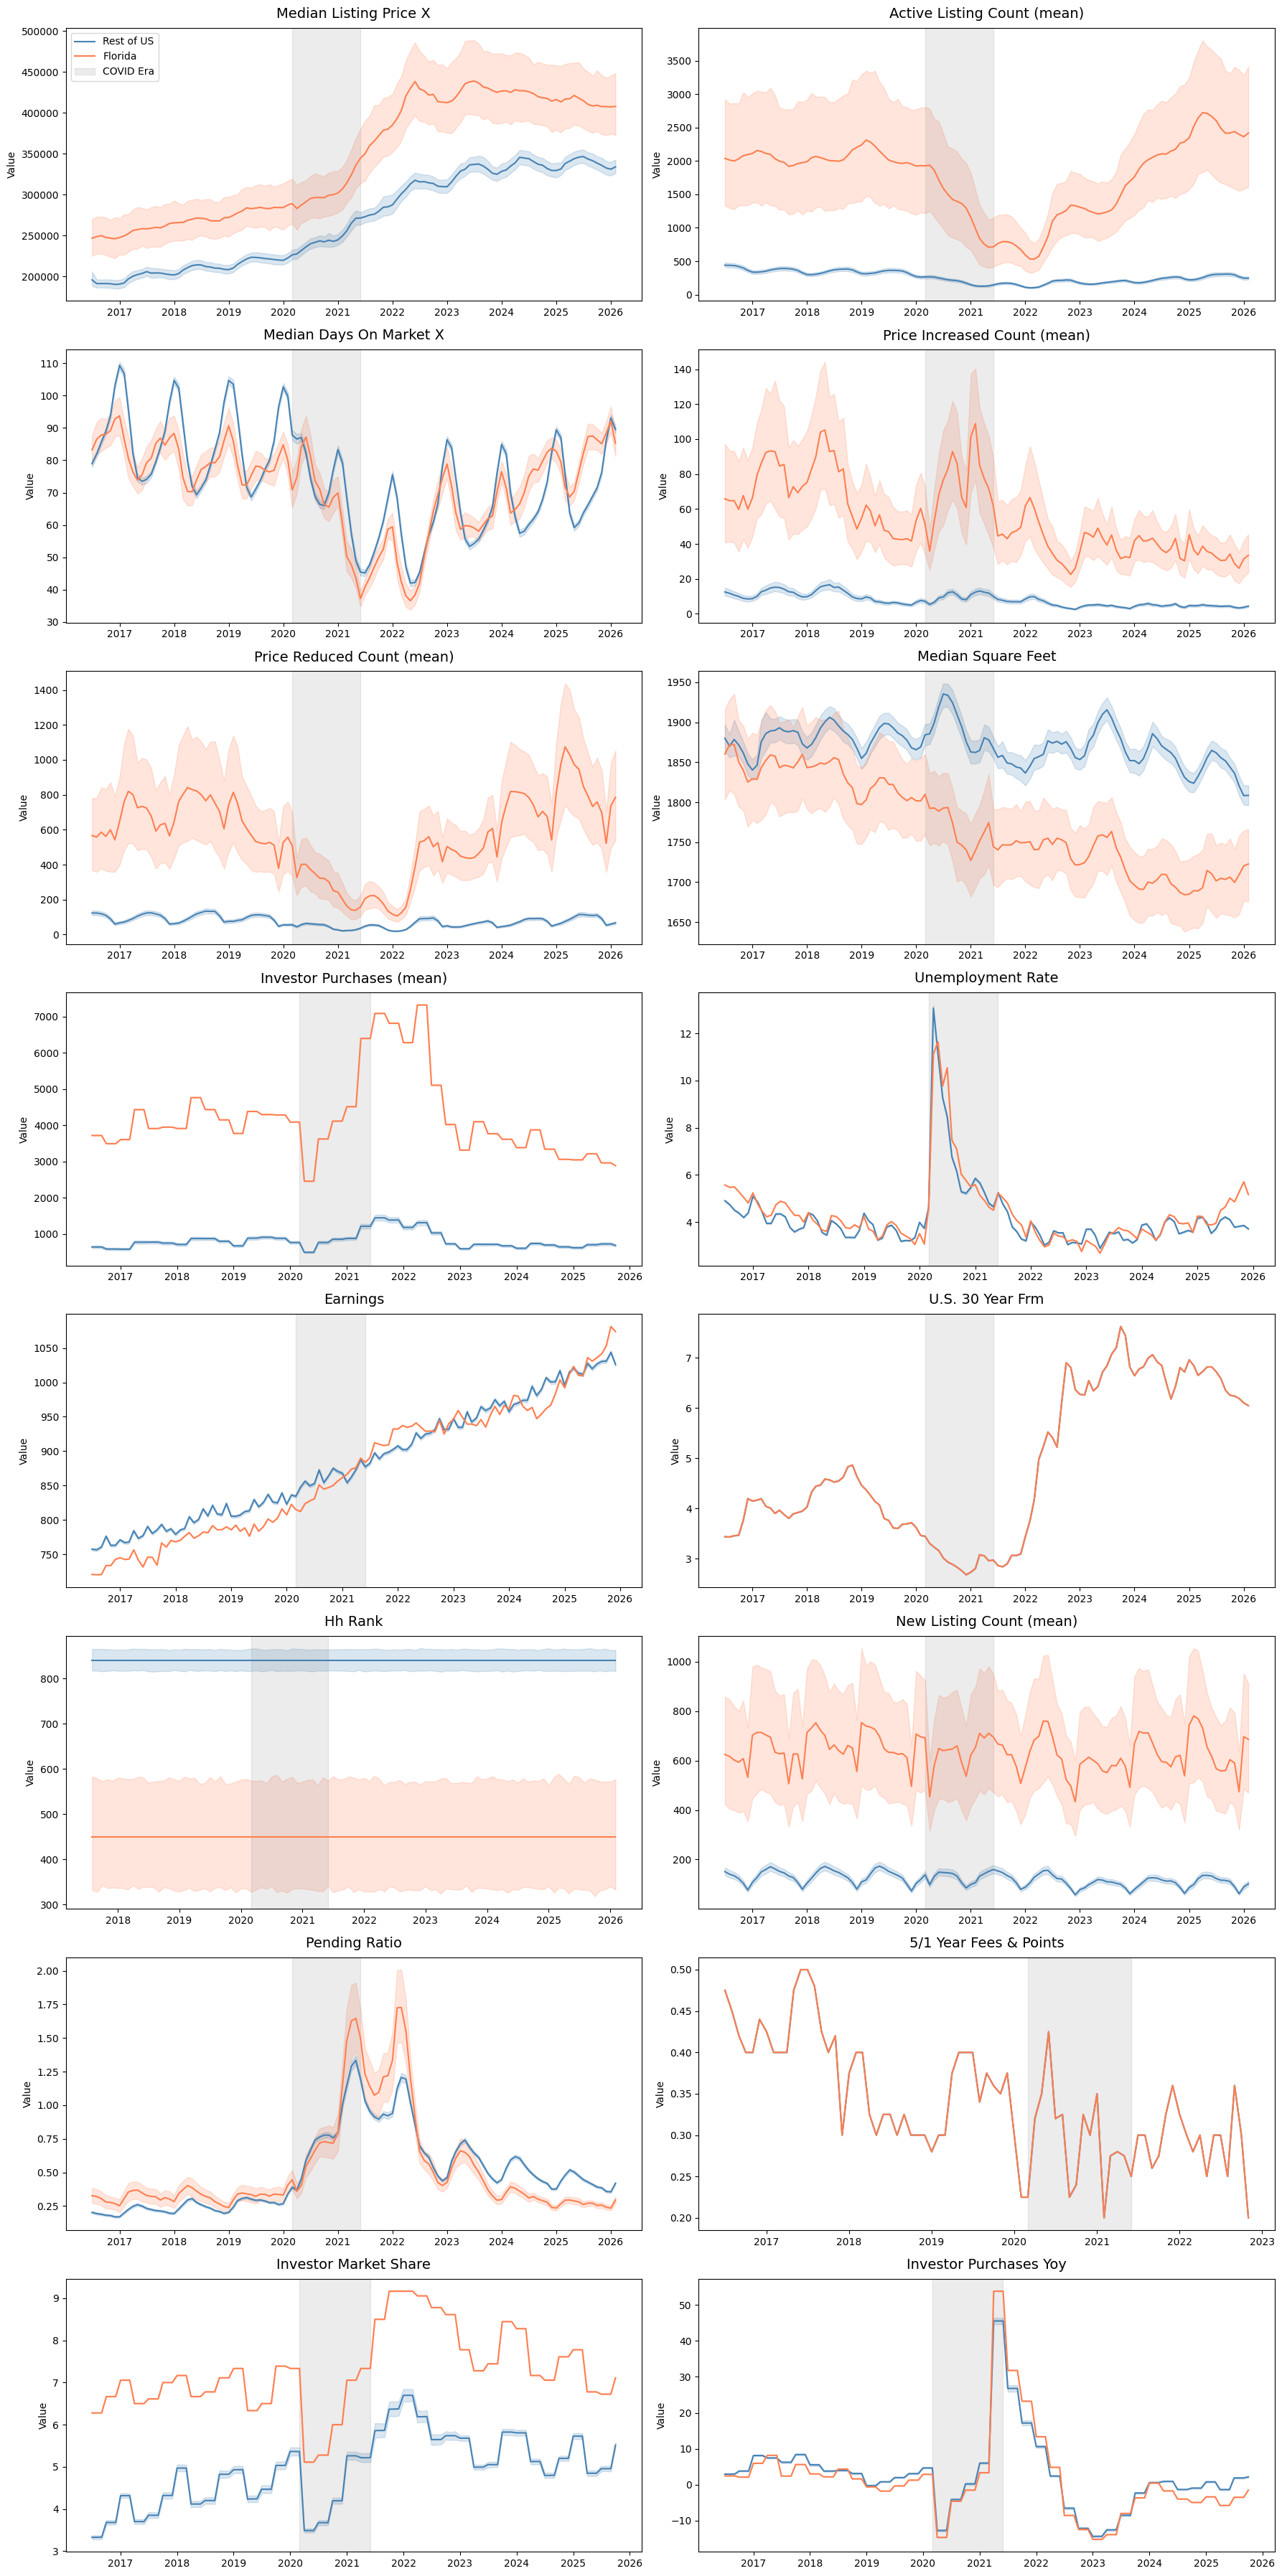

In [10]:
# Convert time column into true Datetime objects so Matplotlib can shade specific dates
# (Assumes your format is YYYYMM like '202003')
df['date'] = pd.to_datetime(df['month_date_yyyymm'].astype(str), format='%Y-%m-%d')

# Create a 'Region' column to split the dataset
df['Region'] = 'Rest of US'

# Change Region value to Florida for state_id = fl
df.loc[df['state'] == 'fl', 'Region'] = 'Florida' 

# Select relevant features to plot

columns_to_plot = [
    'median_listing_price_x', 'active_listing_count', 'median_days_on_market_x', 
    'price_increased_count', 'price_reduced_count', 'median_square_feet',  
    'Investor Purchases', 'Unemployment_Rate', 'Earnings', 'U.S. 30 year FRM',
    'hh_rank', 'new_listing_count', 'pending_ratio', '5/1 year fees & points',
    'Investor Market Share', 'Investor Purchases YoY'
]

# Set up plot
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(18, 36))
axes = axes.flatten()

# Define COVID era shading boundaries (Year-Month-Day)
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-05-31')

import matplotlib.patches as mpatches

# The specific columns that need "(mean)" added to their title
mean_title_cols = [
    'active_listing_count', 
    'price_increased_count', 
    'price_reduced_count', 
    'new_listing_count', 
    'Investor Purchases'
]

# plot
for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # Plot both regions on the same axis (using the default mean estimator)
        sns.lineplot(
            data=df, x='date', y=col, hue='Region', 
            ax=axes[i], palette={'Florida': 'coral', 'Rest of US': 'steelblue'}
        )
        
        # Clean up the titles (e.g., changes 'median_listing_price_x' to 'Median Listing Price X')
        clean_title = col.replace('_', ' ').title()
        
        # APPEND "(mean)" IF IT IS A COUNT VARIABLE
        if col in mean_title_cols:
            clean_title += " (mean)"
            
        axes[i].set_title(clean_title, fontsize=14, pad=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Value')
        
        # Add the light shading for the COVID era
        axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)
        
        # Only keep the legend on the very first plot
        if i == 0:
            covid_patch = mpatches.Patch(color='gray', alpha=0.15, label='COVID Era')
            handles, labels = axes[i].get_legend_handles_labels()
            axes[i].legend(handles=handles + [covid_patch], loc='best')
        else:
            axes[i].get_legend().remove()
            
    else:
        axes[i].set_visible(False)
        print(f"Warning: Column '{col}' not found. Check capitalization!")

# Adjust the layout to keep it looking clean
plt.tight_layout()
plt.show()

